In [1]:
# TDA
import persim
import cripser

# Image
import scipy
import skimage
import matplotlib as mpl

# Anton
import nibabel as nib
import vedo
from parse_brats_for_raph import *

# Comments
import sys
import time
def ChronometerStart(msg='Start... '):
    start_time = time.time()
    sys.stdout.write(msg); sys.stdout.flush()
    return start_time
def ChronometerStop(start_time, method='ms', linebreak='\n'):
    elapsed_time_secs = time.time() - start_time
    if method == 'ms':
        msg = 'Execution time: '+repr(round(elapsed_time_secs*1000))+' ms.'+linebreak
    if method == 's':
        msg = 'Execution time: '+repr(round(elapsed_time_secs))+' s.'+linebreak
    sys.stdout.write(msg); sys.stdout.flush()    

In [2]:
def PlotImage(image, pos, title=None):
    fig, axs = plt.subplots(1, 3, figsize = (8,4))
    for i in range(3):
        if i==0: imageslice = image[pos[0],:,:]
        if i==1: imageslice = image[:,pos[1],:]
        if i==2: imageslice = image[:,:,pos[2]]            
        axs[i].imshow(imageslice,vmin=0, vmax = 1, cmap='gray', origin ='lower')
        axs[i].axis('off')
    if title is not None: fig.suptitle(title,fontsize=10)
    plt.show()
        
def PlotMask(mask, image, pos, title=None):
    COLORS = ['white']+list(mpl.colors.TABLEAU_COLORS)*10
    cmap = mpl.colors.ListedColormap(COLORS[0:(int(np.max(mask))+1)])
    bounds = list(range(int(np.max(mask))+2))
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    fig, axs = plt.subplots(1, 3, figsize = (12,4))
    for i in range(3):
        if i==0: maskslice = mask[pos[0],:,:]; imageslice = image[pos[0],:,:]
        if i==1: maskslice = mask[:,pos[1],:]; imageslice = image[:,pos[1],:]
        if i==2: maskslice = mask[:,:,pos[2]]; imageslice = image[:,:,pos[2]]            
        axs[i].imshow(1-imageslice, cmap='gray', origin ='lower',alpha=0.5)
        axs[i].imshow(maskslice, cmap=cmap, origin ='lower',alpha=0.75,norm=norm)    
        axs[i].axis('off')
    if title is not None: fig.suptitle(title,fontsize=10)
    plt.show()

# Persistence of SRI template

In [3]:
from PIL import Image

In [4]:
image = Image.open('./brain_slices/source_80.png') 
im = np.array(image); im = im/255   

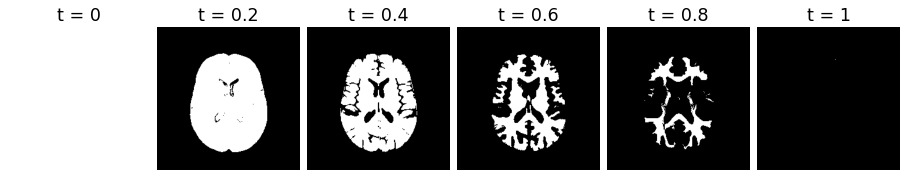

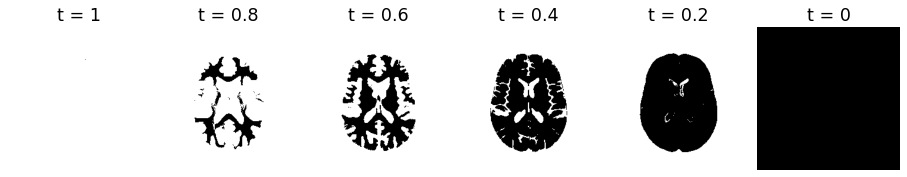

In [8]:
# Sublevels
image = Image.open('./brain_slices/source_80.png') 
im = np.array(image); im = im/255   

fig = plt.figure(figsize=(16,16)) # Notice the equal aspect ratio
ax = [fig.add_subplot(1,6,i+1) for i in range(6)]
Times = [0,0.2,0.4,0.6,0.8,1]
I = list(range(len(Times)))
#ax.reverse()
for i in I:
    t = Times[i]
    a = ax[i]
    a.axis('off')
    a.set_aspect('equal')
    imt = np.zeros(np.shape(im))
    imt[im>=t] = 1
    imt[im<t] = 0
    a.imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
    a.set_title('t = '+repr(t), fontsize=17.5)
fig.subplots_adjust(wspace=0.05, hspace=0)



# Superlevels
image = Image.open('./brain_slices/source_80.png') 
im = np.array(image)[:,:,0]; im = im/255   

fig = plt.figure(figsize=(16,16)) # Notice the equal aspect ratio
ax = [fig.add_subplot(1,6,i+1) for i in range(6)]
Times = [0,0.2,0.4,0.6,0.8,1]
I = list(range(len(Times)))
ax.reverse()
for i in I:
    t = Times[i]
    a = ax[i]
    a.axis('off')
    a.set_aspect('equal')
    imt = np.zeros(np.shape(im))
    imt[im<t] = 1
    imt[im>=t] = 0
    a.imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
    a.set_title('t = '+repr(t), fontsize=17.5)
fig.subplots_adjust(wspace=0.05, hspace=0)

In [11]:
import gudhi

def PersistenceSuperlevel(im):
    if np.max(im)>1:
        raise ValueError('Image non-comprise entre 0 et 1') 
    iminv = 1-im
    xval = np.arange(0, np.shape(im)[0], 1); nx = len(xval)
    yval = np.arange(0, np.shape(im)[0], 1); ny = len(yval)
    cc = gudhi.CubicalComplex(dimensions = [nx ,ny], top_dimensional_cells = np.matrix.flatten(iminv))
    pers = cc.persistence(homology_coeff_field = 2)
    return pers

def PersistenceSublevel(im):
    if np.max(im)>1:
        raise ValueError('Image non-comprise entre 0 et 1') 
    xval = np.arange(0, np.shape(im)[0], 1); nx = len(xval)
    yval = np.arange(0, np.shape(im)[0], 1); ny = len(yval)
    cc = gudhi.CubicalComplex(dimensions = [nx ,ny], top_dimensional_cells = np.matrix.flatten(im))
    pers = cc.persistence(homology_coeff_field = 2)
    return pers

Text(0.5, 1.0, '')

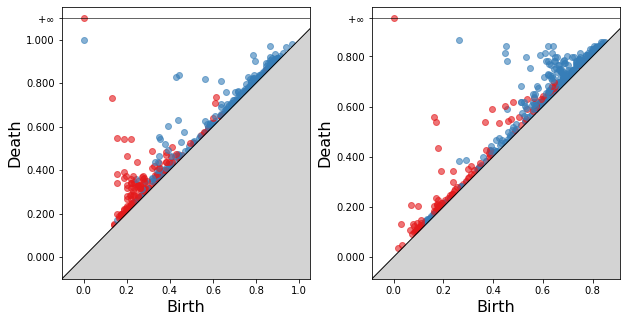

In [12]:
# Open image
image = Image.open('./brain_slices/source_80.png') 
im = np.array(image)[:,:,0]; im = im/255   

# Compute persistence
pers = PersistenceSublevel(im)

# Plot
fig, axs = plt.subplots(1, 2, figsize = (10,5))
#imgplot = axs[0].imshow(im, cmap='gray',origin ='lower'); axs[0].axis('off')
gudhi.plot_persistence_diagram(pers,axes=axs[0], max_intervals=500)
pers = PersistenceSuperlevel(im)
gudhi.plot_persistence_diagram(pers, max_intervals=500, axes=axs[1])
fig.subplots_adjust(wspace=0.25, hspace=0)
axs[0].set_title('')
axs[1].set_title('')

Text(0.5, 1.0, '')

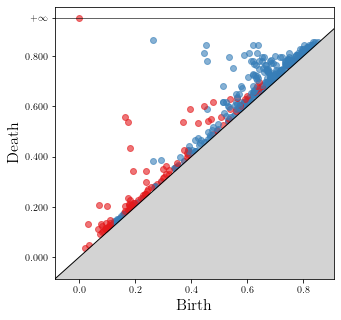

In [66]:
# Open image
image = Image.open('./brain_slices/source_80.png') 
im = np.array(image)[:,:,0]; im = im/255   

# barcode = cripser.computePH(1-im,maxdim=2) # Compute diagram
# H = [(int(bar[0]),(bar[1],min(1,bar[2]))) for bar in barcode]
# plt.figure(figsize=(10,10))
# gudhi.plot_persistence_diagram(H, max_intervals=500)

fig, axs = plt.subplots(1, 1, figsize = (5,5))
#imgplot = axs[0].imshow(im, cmap='gray',origin ='lower'); axs[0].axis('off')
pers = PersistenceSuperlevel(im)
gudhi.plot_persistence_diagram(pers,axes=axs, max_intervals=500)
axs.set_title('')

In [28]:
def GetConnectedComponent(img, pos, t):
    '''
    Get the connected component of the voxel pos = (x,y,z) at time t.
    The output is a binary image.
    Background value of img must be 0 (as conventional).
    '''
    imt = (img>=t)*1
    if imt[pos[0],pos[1]]==0: raise ValueError('The voxel pos is not active at time t.')
    
    labels = skimage.measure.label(imt, background=0)
    labeltumor = labels[pos[0],pos[1]]
    imtumor = (labels == labeltumor)*1
    
    if labeltumor==0: print('Problem! The label is background :(')
        
    return imtumor

(185, 131) 1.7976931348623157e+308
(126, 170) 0.5725490196078431
(126, 70) 0.5568627450980392


(-0.5, 239.5, -0.5, 239.5)

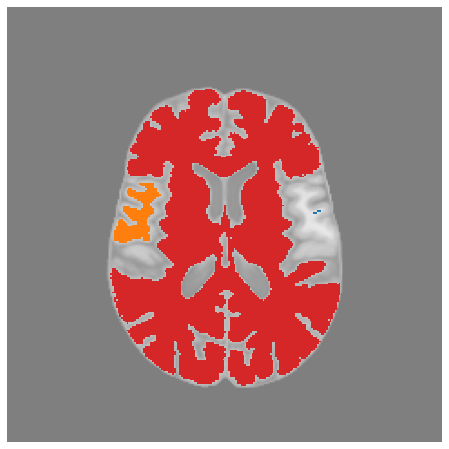

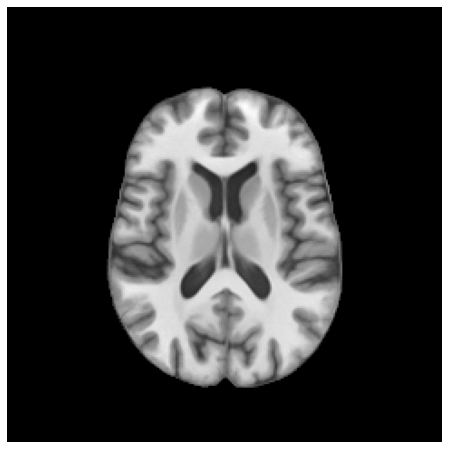

In [137]:
H0 = [list(bar[1::]) for bar in barcode if bar[0]==0] # Only non-infinite bars
H0 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H0],H0))[::-1]] # Sort list H2 by persistence

seg = np.zeros(np.shape(im))

i = 0
pos = (int(H0[i][2]),int(H0[i][3]))
t = H0[i][1]
print(pos, t)
seg += GetConnectedComponent(im,pos,0.5)*1

i = 1
pos = (int(H0[i][2]),int(H0[i][3]))
t = H0[i][1]
print(pos, t)
#seg += GetConnectedComponent(im,pos,t)*2
seg += GetConnectedComponent(im,pos,0.8)*2

i = 2
pos = (int(H0[i][2]),int(H0[i][3]))
t = H0[i][1]
print(pos, t)
seg += GetConnectedComponent(im,pos,t)*3

# i = 3
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,t)*i

from matplotlib.colors import ListedColormap
cmap_segs = ListedColormap(
    [[0,0,0,0],
     'tab:red',
     'tab:blue',
     'tab:orange'
     ])
DLT_KW_IMAGE = dict(cmap='gray',
                      # extent=[-1,1,-1,1],
                      origin='lower',
                      vmin=0,vmax=1)
DLT_KW_SEG= dict(cmap=cmap_segs,
                 interpolation='nearest',
                 origin='lower'
                 )
fig, axs = plt.subplots(1, 1, figsize = (8,8))
axs.imshow(im,alpha=.5,**DLT_KW_IMAGE)
axs.imshow(seg,**DLT_KW_SEG)
plt.axis('off')

fig, axs = plt.subplots(1, 1, figsize = (8,8))
axs.imshow(im,alpha=1,**DLT_KW_IMAGE)
plt.axis('off')

In [134]:
im[(126, 170)]

0.8274509803921568

Text(0.5, 1.0, '')

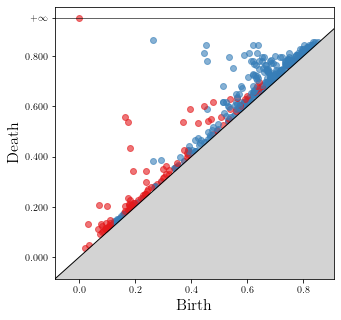

In [94]:
# Open image
image = Image.open('./brain_slices/source_80.png') 
im = np.array(image)[:,:,0]; im = im/255   

# barcode = cripser.computePH(1-im,maxdim=2) # Compute diagram
# H = [(int(bar[0]),(bar[1],min(1,bar[2]))) for bar in barcode]
# plt.figure(figsize=(10,10))
# gudhi.plot_persistence_diagram(H, max_intervals=500)

fig, axs = plt.subplots(1, 1, figsize = (5,5))
#imgplot = axs[0].imshow(im, cmap='gray',origin ='lower'); axs[0].axis('off')
pers = PersistenceSuperlevel(im)
gudhi.plot_persistence_diagram(pers,axes=axs, max_intervals=500)
axs.set_title('')

(138, 141) 0.8666666666666667


(-0.5, 239.5, -0.5, 239.5)

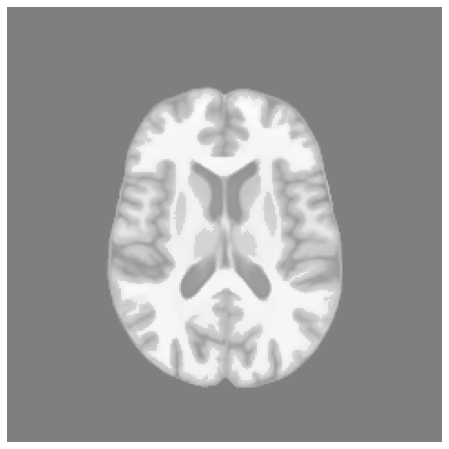

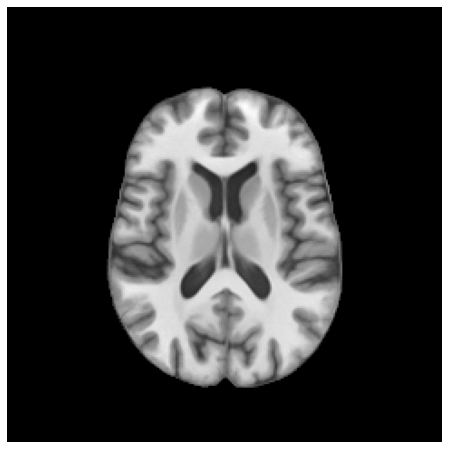

In [121]:
H0 = [list(bar[1::]) for bar in barcode if bar[0]==1] # Only non-infinite bars
H0 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H0],H0))[::-1]] # Sort list H2 by persistence

seg = np.zeros(np.shape(im))

i = 0
pos = (int(H0[i][2]),int(H0[i][3]))
t = H0[i][1]
print(pos, t)
seg += GetConnectedComponent(im,pos,0.7)*1

# i = 1
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,0.4)*2

# i = 2
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,0.53)*3

# i = 3
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,t)*i

from matplotlib.colors import ListedColormap
cmap_segs = ListedColormap(
    [[0,0,0,0],
     'black',
     'tab:red',
     'tab:blue',
     'white'
     ])
DLT_KW_IMAGE = dict(cmap='gray',
                      # extent=[-1,1,-1,1],
                      origin='lower',
                      vmin=0,vmax=1)
DLT_KW_SEG= dict(cmap=cmap_segs,
                 interpolation='nearest',
                 origin='lower'
                 )
fig, axs = plt.subplots(1, 1, figsize = (8,8))
axs.imshow(im,alpha=.5,**DLT_KW_IMAGE)
axs.imshow(seg,alpha=0.5,**DLT_KW_SEG)
plt.axis('off')

fig, axs = plt.subplots(1, 1, figsize = (8,8))
axs.imshow(im,alpha=1,**DLT_KW_IMAGE)
plt.axis('off')

(106, 115) 0.8431372549019608


(-0.5, 239.5, -0.5, 239.5)

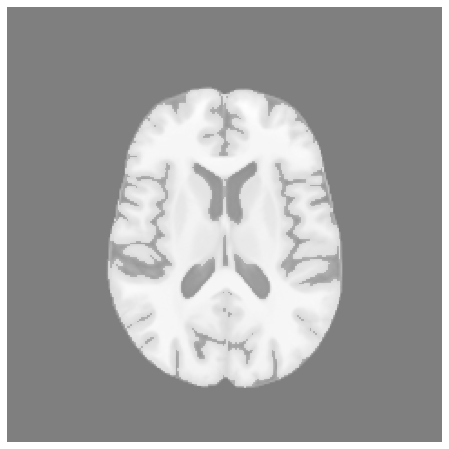

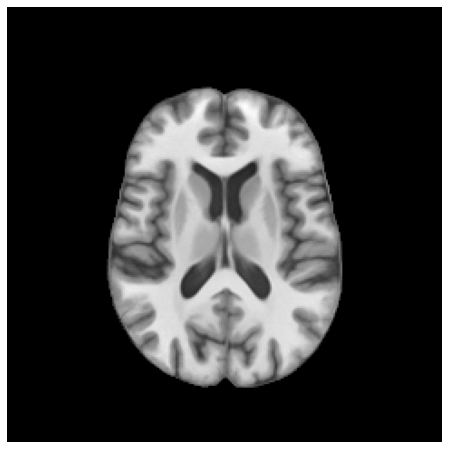

In [123]:
H0 = [list(bar[1::]) for bar in barcode if bar[0]==1] # Only non-infinite bars
H0 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H0],H0))[::-1]] # Sort list H2 by persistence

seg = np.zeros(np.shape(im))

# i = 0
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,0.7)*1

i = 1
pos = (int(H0[i][2]),int(H0[i][3]))
t = H0[i][1]
print(pos, t)
seg += GetConnectedComponent(im,pos,0.4)*1

# i = 2
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,0.53)*3

# i = 3
# pos = (int(H0[i][2]),int(H0[i][3]))
# t = H0[i][1]
# print(pos, t)
# seg += GetConnectedComponent(im,pos,t)*i

from matplotlib.colors import ListedColormap
cmap_segs = ListedColormap(
    [[0,0,0,0],
     'black',
     'tab:red',
     'tab:blue',
     'white'
     ])
DLT_KW_IMAGE = dict(cmap='gray',
                      # extent=[-1,1,-1,1],
                      origin='lower',
                      vmin=0,vmax=1)
DLT_KW_SEG= dict(cmap=cmap_segs,
                 interpolation='nearest',
                 origin='lower'
                 )
fig, axs = plt.subplots(1, 1, figsize = (8,8))
axs.imshow(im,alpha=.5,**DLT_KW_IMAGE)
axs.imshow(seg,alpha=0.5,**DLT_KW_SEG)
plt.axis('off')

fig, axs = plt.subplots(1, 1, figsize = (8,8))
axs.imshow(im,alpha=1,**DLT_KW_IMAGE)
plt.axis('off')